## 기본 함수 삽입

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.api import qqplot, add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import os
os.chdir("/home/piai/Desktop/git/2. Big Data 분석")

matplotlib.rc("font", family = "NanumSquare")
matplotlib.rc("axes", unicode_minus = False)

# 1번

In [2]:
df_raw = pd.read_csv("보험료.csv", encoding = 'cp949')
df_raw.head()

,고객번호,성별,나이,BMI,자녀수,흡연여부,가입유형,납부유형,보장범위,납입기간,보험료
0,ID100001,남성,19,27.9,0,1,홈쇼핑,은행,19,40,168849
1,ID100002,여성,18,33.8,1,0,인터넷,은행,10,40,17255
2,ID100003,여성,28,33.0,3,0,상담사,카드,12,30,44494
3,ID100004,여성,33,22.7,0,0,홈쇼핑,지로,15,30,219844
4,ID100005,여성,32,28.9,0,0,인터넷,카드,9,30,38668


## 결측치 처리

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1343 entries, 0 to 1342
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   고객번호    1343 non-null   object 
 1   성별      1343 non-null   object 
 2   나이      1343 non-null   int64  
 3   BMI     1343 non-null   float64
 4   자녀수     1343 non-null   int64  
 5   흡연여부    1343 non-null   int64  
 6   가입유형    1341 non-null   object 
 7   납부유형    1340 non-null   object 
 8   보장범위    1343 non-null   int64  
 9   납입기간    1343 non-null   int64  
 10  보험료     1343 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 115.5+ KB


In [4]:
df_raw.isnull().sum()

고객번호    0
성별      0
나이      0
BMI     0
자녀수     0
흡연여부    0
가입유형    2
납부유형    3
보장범위    0
납입기간    0
보험료     0
dtype: int64

결측치를 가지고 있는 유형이 모두 문자형인 것을 알 수 있었다.<br>
그러므로 최빈값을 활용하여 결측치를 제거한다.

In [5]:
print(df_raw['가입유형'].value_counts())
df_raw['가입유형'].fillna(df_raw['가입유형'].mode()[0], inplace = True)

인터넷    574
홈쇼핑    385
상담사    382
Name: 가입유형, dtype: int64


In [6]:
print(df_raw['납부유형'].mode())
df_raw['납부유형'].fillna(df_raw['납부유형'].mode()[0], inplace = True)

0    카드
Name: 납부유형, dtype: object


In [7]:
df_raw.isnull().sum()

고객번호    0
성별      0
나이      0
BMI     0
자녀수     0
흡연여부    0
가입유형    0
납부유형    0
보장범위    0
납입기간    0
보험료     0
dtype: int64

## 변수 처리

In [8]:
df_raw

,고객번호,성별,나이,BMI,자녀수,흡연여부,가입유형,납부유형,보장범위,납입기간,보험료
0,ID100001,남성,19,27.9,0,1,홈쇼핑,은행,19,40,168849
1,ID100002,여성,18,33.8,1,0,인터넷,은행,10,40,17255
2,ID100003,여성,28,33.0,3,0,상담사,카드,12,30,44494
3,ID100004,여성,33,22.7,0,0,홈쇼핑,지로,15,30,219844
4,ID100005,여성,32,28.9,0,0,인터넷,카드,9,30,38668
...,...,...,...,...,...,...,...,...,...,...,...
1338,ID101339,여성,50,31.0,3,0,홈쇼핑,지로,10,20,106005
1339,ID101340,남성,18,31.9,0,0,인터넷,카드,8,30,22059
1340,ID101341,남성,18,36.9,0,0,인터넷,은행,9,40,16298
1341,ID101342,남성,21,25.8,0,0,인터넷,은행,8,30,20079


In [9]:
# 사용하지 않는 변수를 제거 한다.
df_raw = df_raw.drop(['고객번호'], axis = 1)

df_raw_dummy = pd.get_dummies(df_raw, drop_first = True)
df_raw_dummy.head()

,나이,BMI,자녀수,흡연여부,보장범위,납입기간,보험료,성별_여성,가입유형_인터넷,가입유형_홈쇼핑,납부유형_지로,납부유형_카드
0,19,27.9,0,1,19,40,168849,0,0,1,0,0
1,18,33.8,1,0,10,40,17255,1,1,0,0,0
2,28,33.0,3,0,12,30,44494,1,0,0,0,1
3,33,22.7,0,0,15,30,219844,1,0,1,1,0
4,32,28.9,0,0,9,30,38668,1,1,0,0,1


In [10]:
df_raw_dummy['보험료_천원'] = df_raw_dummy['보험료']/1000

## 상관관계 분석

In [11]:
df_raw_dummy.corr().round(3)

,나이,BMI,자녀수,흡연여부,보장범위,납입기간,보험료,성별_여성,가입유형_인터넷,가입유형_홈쇼핑,납부유형_지로,납부유형_카드,보험료_천원
나이,1.000,0.108,0.045,-0.021,-0.019,-0.826,0.302,-0.018,-0.020,-0.018,-0.003,-0.023,0.302
BMI,0.108,1.000,0.013,0.003,0.015,-0.139,0.198,0.046,-0.020,-0.025,0.017,0.001,0.198
자녀수,0.045,0.013,1.000,0.007,0.188,-0.039,0.068,0.021,-0.012,-0.028,-0.026,0.022,0.068
흡연여부,-0.021,0.003,0.007,1.000,0.701,0.045,0.788,0.075,-0.086,0.058,0.002,-0.001,0.788
보장범위,-0.019,0.015,0.188,0.701,1.000,0.144,0.704,-0.005,-0.092,0.064,0.025,0.001,0.704
납입기간,-0.826,-0.139,-0.039,0.045,0.144,1.000,-0.283,0.055,0.028,0.007,0.012,0.003,-0.283
보험료,0.302,0.198,0.068,0.788,0.704,-0.283,1.000,0.058,-0.097,0.048,0.015,0.001,1.000
성별_여성,-0.018,0.046,0.021,0.075,-0.005,0.055,0.058,1.000,0.014,-0.027,-0.005,0.035,0.058
가입유형_인터넷,-0.020,-0.020,-0.012,-0.086,-0.092,0.028,-0.097,0.014,1.000,-0.549,-0.005,-0.002,-0.097
가입유형_홈쇼핑,-0.018,-0.025,-0.028,0.058,0.064,0.007,0.048,-0.027,-0.549,1.000,0.111,-0.064,0.048


상관관계 분석 결과 흡연여부, 보장범위가 강한 상관성을 가지고 있는 것을 알 수 있다.

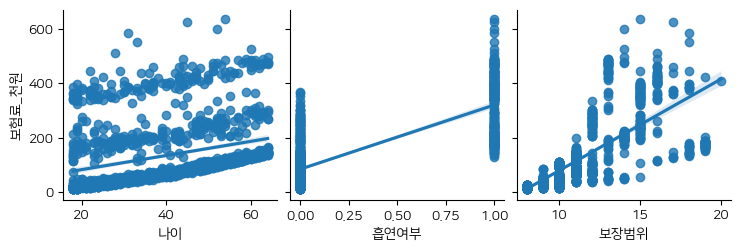

In [12]:
sns.pairplot(df_raw_dummy, y_vars="보험료_천원", x_vars=["나이", "흡연여부", "보장범위"], kind = "reg")

상관관계가 가장 높은 변수 3개를 그래프로 확인해보았다.<br>
중간 확인 결과, 나이의 그래프가 크게 3개층으로 이루어진 것으로 보아, 보험료에 층을 만드는 특정 요인이 존재할 수 있다는 것을 유추할 수 있다.<br>
또한, 흡연 여부에 따라 보험료가 유의미한 차이를 보이고 있다.<br>

### 특정요인 찾아보기

변수 중 3개층으로 나누어지는 변수는 납입기간, 가입유형, 납부유형이 있다.<br>
변수별로 분리한 후, 나이별 보험료를 다시 계산해보았다.<br>

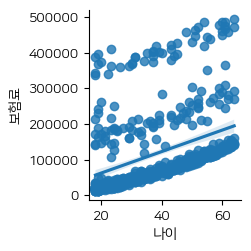

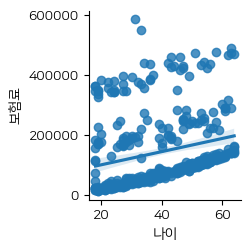

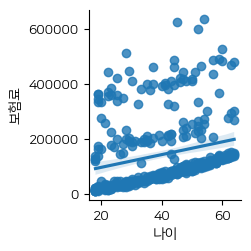

In [13]:
df_internet = df_raw[df_raw['가입유형'] == '인터넷'][['나이', '보험료']]
df_homeshopping = df_raw[df_raw['가입유형'] == '홈쇼핑'][['나이', '보험료']]
df_counselor = df_raw[df_raw['가입유형'] == '상담사'][['나이', '보험료']]
sns.pairplot(df_internet, y_vars="보험료", x_vars=["나이"], kind = "reg")
sns.pairplot(df_homeshopping, y_vars="보험료", x_vars=["나이"], kind = "reg")
sns.pairplot(df_counselor, y_vars="보험료", x_vars=["나이"], kind = "reg")

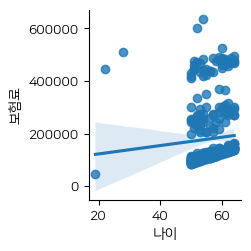

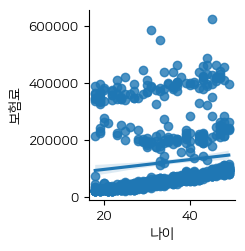

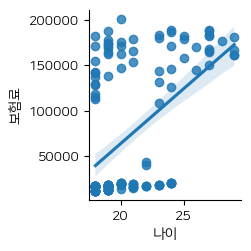

In [14]:
df_20 = df_raw[df_raw['납입기간'] == 20][['나이', '보험료']]
df_30 = df_raw[df_raw['납입기간'] == 30][['나이', '보험료']]
df_40 = df_raw[df_raw['납입기간'] == 40][['나이', '보험료']]
sns.pairplot(df_20, y_vars="보험료", x_vars=["나이"], kind = "reg")
sns.pairplot(df_30, y_vars="보험료", x_vars=["나이"], kind = "reg")
sns.pairplot(df_40, y_vars="보험료", x_vars=["나이"], kind = "reg")

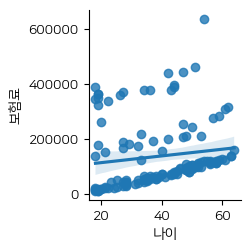

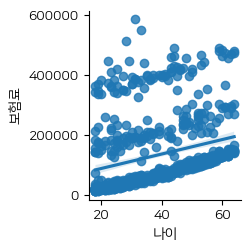

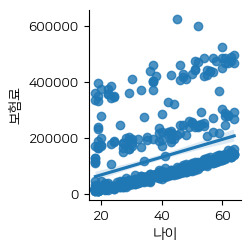

In [15]:
df_giro = df_raw[df_raw['납부유형'] == '지로'][['나이', '보험료']]
df_card = df_raw[df_raw['납부유형'] == '카드'][['나이', '보험료']]
df_bank = df_raw[df_raw['납부유형'] == '은행'][['나이', '보험료']]
sns.pairplot(df_giro, y_vars="보험료", x_vars=["나이"], kind = "reg")
sns.pairplot(df_card, y_vars="보험료", x_vars=["나이"], kind = "reg")
sns.pairplot(df_bank, y_vars="보험료", x_vars=["나이"], kind = "reg")

분석 결과 아쉽게도 구분하는 요인을 발견하지 못했다. 회귀분석으로 넘어가서 종합적인 분석을 시행한다.

## 데이터 분리

In [16]:
df_train, df_test = train_test_split(df_raw_dummy, test_size = 0.3, random_state = 1234) 
print("train data size : {}".format(df_train.shape))
print("test data size : {}".format(df_test.shape))

train data size : (940, 13)
test data size : (403, 13)


In [17]:
reg_model = smf.ols(formula = "보험료_천원 ~ 나이 + BMI + 자녀수 + 흡연여부 + 보장범위 + 납입기간 + 성별_여성 + 가입유형_인터넷 + 가입유형_홈쇼핑 + 납부유형_지로 + 납부유형_카드", data = df_train)

reg_result = reg_model.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:                 보험료_천원   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     379.8
Date:                Mon, 27 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:55:26   Log-Likelihood:                -5047.7
No. Observations:                 940   AIC:                         1.012e+04
Df Residuals:                     928   BIC:                         1.018e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -22.0449     24.468     -0.901      0.3

In [18]:
df_train_x = df_train.drop(['보험료_천원', '보험료'], axis = 1)
df_train_x_const = add_constant(df_train_x) 
df_vif = pd.DataFrame()
df_vif["variable"] = df_train_x_const.columns
df_vif["VIF"] = [variance_inflation_factor(df_train_x_const.values, i) \
                 for i in range(df_train_x_const.shape[1])]
df_vif.sort_values("VIF", ascending = True).round(2)

,variable,VIF
2,BMI,1.04
7,성별_여성,1.04
3,자녀수,1.08
11,납부유형_카드,1.14
10,납부유형_지로,1.15
8,가입유형_인터넷,1.51
9,가입유형_홈쇼핑,1.53
4,흡연여부,2.18
5,보장범위,2.33
1,나이,3.28


In [19]:
#1번 자녀수 제거
reg_model = smf.ols(formula = "보험료_천원 ~ 나이 + BMI + 흡연여부 + 보장범위 + 납입기간 + 성별_여성 + 가입유형_인터넷 + 가입유형_홈쇼핑 + 납부유형_지로 + 납부유형_카드", data = df_train)

reg_result = reg_model.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:                 보험료_천원   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     418.2
Date:                Mon, 27 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:55:26   Log-Likelihood:                -5047.8
No. Observations:                 940   AIC:                         1.012e+04
Df Residuals:                     929   BIC:                         1.017e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -22.0905     24.455     -0.903      0.3

In [20]:
#2번 납부유형_지로 제거
reg_model = smf.ols(formula = "보험료_천원 ~ 나이 + BMI + 흡연여부 + 보장범위 + 납입기간 + 성별_여성 + 가입유형_인터넷 + 가입유형_홈쇼핑 + 납부유형_카드", data = df_train)

reg_result = reg_model.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:                 보험료_천원   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     465.0
Date:                Mon, 27 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:55:26   Log-Likelihood:                -5047.9
No. Observations:                 940   AIC:                         1.012e+04
Df Residuals:                     930   BIC:                         1.016e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -21.4742     24.400     -0.880      0.3

In [21]:
#3번 가입유형_인터넷 제거
reg_model = smf.ols(formula = "보험료_천원 ~ 나이 + BMI + 흡연여부 + 보장범위 + 납입기간 + 성별_여성 + 가입유형_홈쇼핑 + 납부유형_카드", data = df_train)

reg_result = reg_model.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:                 보험료_천원   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     523.6
Date:                Mon, 27 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:55:27   Log-Likelihood:                -5048.0
No. Observations:                 940   AIC:                         1.011e+04
Df Residuals:                     931   BIC:                         1.016e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -22.8309     24.212     -0.943      0.3

In [22]:
#4번 납부유형_카드 제거
reg_model = smf.ols(formula = "보험료_천원 ~ 나이 + BMI + 흡연여부 + 보장범위 + 납입기간 + 성별_여성 + 가입유형_홈쇼핑", data = df_train)

reg_result = reg_model.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:                 보험료_천원   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     598.5
Date:                Mon, 27 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:55:27   Log-Likelihood:                -5048.3
No. Observations:                 940   AIC:                         1.011e+04
Df Residuals:                     932   BIC:                         1.015e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -20.8263     24.078     -0.865      0.3

In [23]:
#5번 가입유형_홈쇼핑 제거
reg_model = smf.ols(formula = "보험료_천원 ~ 나이 + BMI + 흡연여부 + 보장범위 + 납입기간 + 성별_여성", data = df_train)

reg_result = reg_model.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:                 보험료_천원   R-squared:                       0.818
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     698.0
Date:                Mon, 27 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:55:27   Log-Likelihood:                -5048.9
No. Observations:                 940   AIC:                         1.011e+04
Df Residuals:                     933   BIC:                         1.015e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -22.9178     24.001     -0.955      0.3

In [24]:
#6번 나이 제거
reg_model = smf.ols(formula = "보험료_천원 ~ BMI + 흡연여부 + 보장범위 + 납입기간 + 성별_여성", data = df_train)

reg_result = reg_model.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:                 보험료_천원   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     835.5
Date:                Mon, 27 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:55:27   Log-Likelihood:                -5050.2
No. Observations:                 940   AIC:                         1.011e+04
Df Residuals:                     934   BIC:                         1.014e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.9363     15.177      0.523      0.6

In [25]:
#7번 성별_여성 제거
reg_model = smf.ols(formula = "보험료_천원 ~ BMI + 흡연여부 + 보장범위 + 납입기간", data = df_train)

reg_result = reg_model.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:                 보험료_천원   R-squared:                       0.817
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     1041.
Date:                Mon, 27 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:55:27   Log-Likelihood:                -5051.9
No. Observations:                 940   AIC:                         1.011e+04
Df Residuals:                     935   BIC:                         1.014e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.3386     15.139      0.683      0.4

In [26]:
df_train_x = df_train[["BMI","흡연여부", "보장범위", "납입기간"]]
df_train_x_const = add_constant(df_train_x) 
df_vif = pd.DataFrame()
df_vif["variable"] = df_train_x_const.columns
df_vif["VIF"] = [variance_inflation_factor(df_train_x_const.values, i) for i in range(df_train_x_const.shape[1])]

df_vif.sort_values('VIF', inplace = True)
df_vif.round(2)

,variable,VIF
1,BMI,1.02
4,납입기간,1.06
2,흡연여부,2.00
3,보장범위,2.05
0,const,78.59


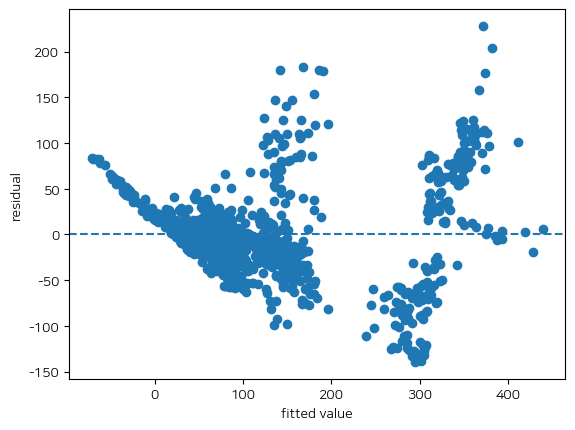

In [27]:
plt.scatter(reg_result.fittedvalues, reg_result.resid)
plt.xlabel("fitted value")
plt.ylabel("residual")
plt.axhline(y = 0, linestyle = "--")

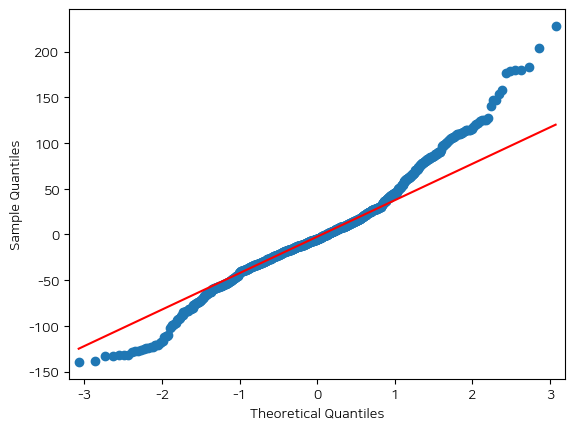

In [28]:
qqplot(reg_result.resid, line = "q")
plt.show()

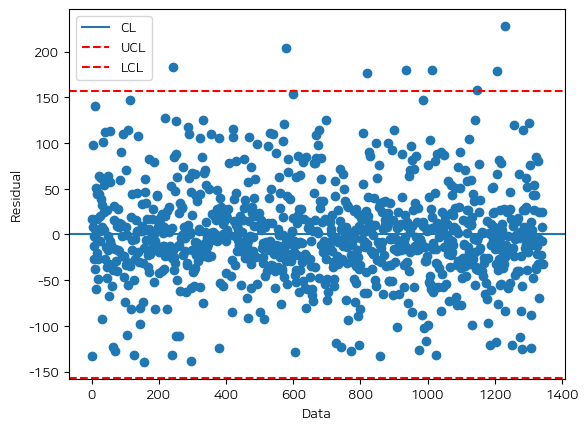

In [29]:
plt.scatter(df_train.index, reg_result.resid)
plt.xlabel("Data")  ;  plt.ylabel("Residual")
plt.axhline(y=0,linestyle="-", label='CL')
plt.axhline(y=3*np.std(reg_result.resid),linestyle="--",color="red",label='UCL' )
plt.axhline(y=-3*np.std(reg_result.resid),linestyle="dashed",color="red",label='LCL')
plt.legend(loc = 'best')
plt.show()

In [30]:
train_pred = reg_result.predict(df_train)
test_pred = reg_result.predict(df_test)
print("train data의 결정계수:", r2_score(df_train['보험료_천원'], train_pred))
print("test data의 결정계수:", r2_score(df_test['보험료_천원'], test_pred))

train data의 결정계수: 0.8166112844735576
test data의 결정계수: 0.8018480053619719


<Axes: >

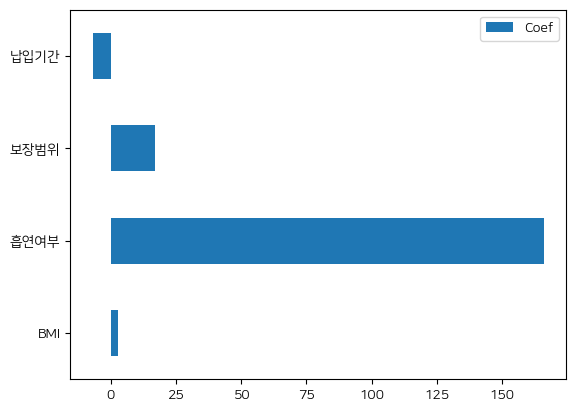

In [31]:
df_reg_coef = pd.DataFrame({"Coef": reg_result.params.values[1:]},  
                           index = ["BMI","흡연여부", "보장범위", "납입기간"])
df_reg_coef.plot.barh(y = "Coef")

## 로그 변환 후 분석 재시행

In [32]:
df_raw_dummy['보험료'] = np.log(df_raw_dummy['보험료'])

In [33]:
df_train, df_test = train_test_split(df_raw_dummy, test_size = 0.3, random_state = 1234) 
print("train data size : {}".format(df_train.shape))
print("test data size : {}".format(df_test.shape))

train data size : (940, 13)
test data size : (403, 13)


In [34]:
reg_model = smf.ols(formula = "보험료 ~ BMI + 흡연여부 + 보장범위 + 납입기간", data = df_train)

reg_result = reg_model.fit()
print(reg_result.summary())

                            OLS Regression Results                            
Dep. Variable:                    보험료   R-squared:                       0.911
Model:                            OLS   Adj. R-squared:                  0.911
Method:                 Least Squares   F-statistic:                     2404.
Date:                Mon, 27 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:55:28   Log-Likelihood:                -118.89
No. Observations:                 940   AIC:                             247.8
Df Residuals:                     935   BIC:                             272.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.6849      0.080    134.217      0.0

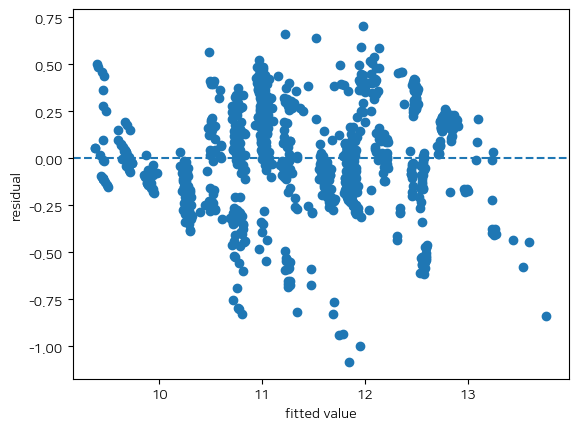

In [35]:
plt.scatter(reg_result.fittedvalues, reg_result.resid)
plt.xlabel("fitted value")
plt.ylabel("residual")
plt.axhline(y = 0, linestyle = "--")

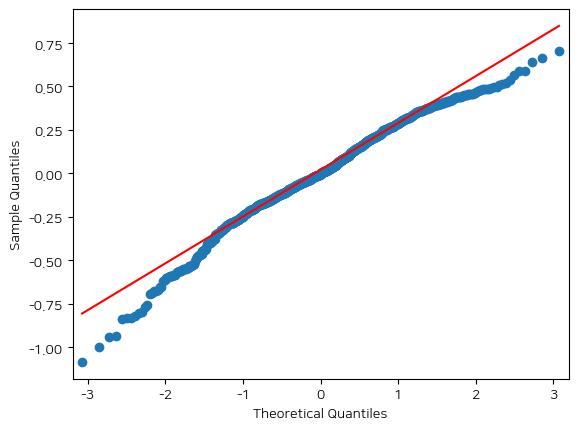

In [36]:
qqplot(reg_result.resid, line = "q")
plt.show()

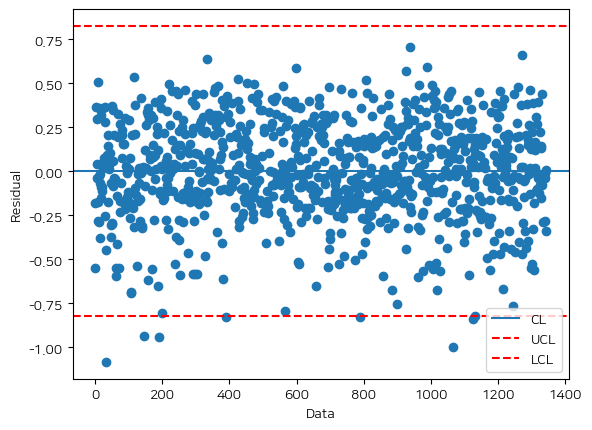

In [37]:
plt.scatter(df_train.index, reg_result.resid)
plt.xlabel("Data")  ;  plt.ylabel("Residual")
plt.axhline(y=0,linestyle="-", label='CL')
plt.axhline(y=3*np.std(reg_result.resid),linestyle="--",color="red",label='UCL' )
plt.axhline(y=-3*np.std(reg_result.resid),linestyle="dashed",color="red",label='LCL')
plt.legend(loc = 'best')
plt.show()

In [38]:
train_pred = reg_result.predict(df_train)
test_pred = reg_result.predict(df_test)
print("train data의 결정계수:", r2_score(df_train['보험료'], train_pred))
print("test data의 결정계수:", r2_score(df_test['보험료'], test_pred))

train data의 결정계수: 0.9113684311079674
test data의 결정계수: 0.9125403562472301


<Axes: >

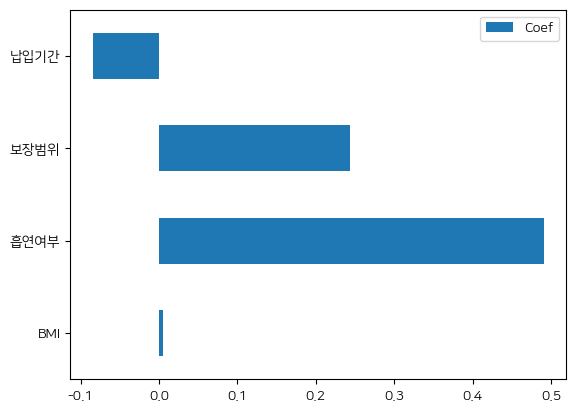

In [39]:
df_reg_coef = pd.DataFrame({"Coef": reg_result.params.values[1:]},  
                           index = ["BMI","흡연여부", "보장범위", "납입기간"])
df_reg_coef.plot.barh(y = "Coef")

## 분석결과

하지만 해당 모델은 정규성과 등분산성을 만족하지 않는다는 단점이 있다.<br>
데이터의 수가 많아 중심극한정리로 정규성을 만족할 수 있지만, 등분산성은 만족하지 않는다는 위험이 존재한다.<br>
그러므로 보험료가 높은 구간에서 예측 오차가 커질 수 있다는 한계점이 있다.<br>

그럼에도 본 회귀모형은 결정계수가 0.912로 매우 높은 설명력을 자랑하였다.<br>
특히, 흡연여부는 보험료에 지대한 영향을 미쳤으며, 납입기간은 음의 상관성을 가진다는 특징이 있다.<br>
위 결과를 통해 흡연 여부와 보장범위 정도가 보험료에 중요한 영향을 미침을 알 수 있었다.<br>
보장여부는 보험효과 발생 시 보장을 최대화하기 위함으로 당위성 있는 요인이지만, 흡연여부는 흡연자의 건강이 비흡연자 대비 악화되기 쉬움을 나타낸다.<br>
그러므로, 보험 가입자는 스스로의 건강을 보험으로 챙기기 전에 금연으로 챙기는 것이 금전적으로, 건강적으로 아낄 수 있는 길이다.

# 2번

### 데이터가 동일하여 전처리 데이터 그대로 활용

In [40]:
df_raw_y = df_raw_dummy["보험료"]
df_raw_x = df_raw_dummy.drop(["보험료_천원", "보험료"], axis = 1)

In [41]:
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y, test_size = 0.3, random_state = 1234) 
print("train data X size : {}".format(df_train_x.shape))
print("train data Y size : {}".format(df_train_y.shape))
print("test data X size : {}".format(df_test_x.shape))
print("test data Y size : {}".format(df_test_y.shape))

train data X size : (940, 11)
train data Y size : (940,)
test data X size : (403, 11)
test data Y size : (403,)


In [42]:
alpha = [0.01, 0.1, 1, 10, 100]

### 릿지

In [43]:
for i in alpha:
    ridge = Ridge(random_state=1234, alpha = i)
    ridge.fit(df_train_x, df_train_y)
    train_pred = ridge.predict(df_train_x)
    test_pred = ridge.predict(df_test_x)
    print(f"alpha가 {i}일때, train data의 결정계수:", r2_score(df_train_y, train_pred).round(3))
    print(f"alpha가 {i}일때, test data의 결정계수:", r2_score(df_test_y, test_pred).round(3))
    print("")

alpha가 0.01일때, train data의 결정계수: 0.933
alpha가 0.01일때, test data의 결정계수: 0.941

alpha가 0.1일때, train data의 결정계수: 0.933
alpha가 0.1일때, test data의 결정계수: 0.941

alpha가 1일때, train data의 결정계수: 0.933
alpha가 1일때, test data의 결정계수: 0.941

alpha가 10일때, train data의 결정계수: 0.932
alpha가 10일때, test data의 결정계수: 0.941

alpha가 100일때, train data의 결정계수: 0.924
alpha가 100일때, test data의 결정계수: 0.934



### 라쏘

In [44]:
for i in alpha:
    lasso = Lasso(random_state=1234, alpha = i)
    lasso.fit(df_train_x, df_train_y)
    train_pred = lasso.predict(df_train_x)
    test_pred = lasso.predict(df_test_x)
    print(f"alpha가 {i}일때, train data의 결정계수:", r2_score(df_train_y, train_pred).round(3))
    print(f"alpha가 {i}일때, test data의 결정계수:", r2_score(df_test_y, test_pred).round(3))
    print("")

alpha가 0.01일때, train data의 결정계수: 0.931
alpha가 0.01일때, test data의 결정계수: 0.941

alpha가 0.1일때, train data의 결정계수: 0.899
alpha가 0.1일때, test data의 결정계수: 0.912

alpha가 1일때, train data의 결정계수: 0.661
alpha가 1일때, test data의 결정계수: 0.716

alpha가 10일때, train data의 결정계수: 0.0
alpha가 10일때, test data의 결정계수: -0.008

alpha가 100일때, train data의 결정계수: 0.0
alpha가 100일때, test data의 결정계수: -0.008



### 엘라스틱 넷

In [45]:
l1_ratio = [0.3, 0.5, 0.7]

In [46]:
for i in alpha:
    for j in l1_ratio:
        elastic = ElasticNet(random_state=1234, alpha = i, l1_ratio = j)
        elastic.fit(df_train_x, df_train_y)
        train_pred =elastic.predict(df_train_x)
        test_pred = elastic.predict(df_test_x)
        print(f"alpha가 {i}이고, l1_ratio인 경우, train data의 결정계수:", r2_score(df_train_y, train_pred).round(3))
        print(f"alpha가 {i}이고, l1_ratio인 경우, test data의 결정계수:", r2_score(df_test_y, test_pred).round(3))
        print("")

alpha가 0.01이고, l1_ratio인 경우, train data의 결정계수: 0.932
alpha가 0.01이고, l1_ratio인 경우, test data의 결정계수: 0.942

alpha가 0.01이고, l1_ratio인 경우, train data의 결정계수: 0.931
alpha가 0.01이고, l1_ratio인 경우, test data의 결정계수: 0.942

alpha가 0.01이고, l1_ratio인 경우, train data의 결정계수: 0.931
alpha가 0.01이고, l1_ratio인 경우, test data의 결정계수: 0.941

alpha가 0.1이고, l1_ratio인 경우, train data의 결정계수: 0.914
alpha가 0.1이고, l1_ratio인 경우, test data의 결정계수: 0.926

alpha가 0.1이고, l1_ratio인 경우, train data의 결정계수: 0.903
alpha가 0.1이고, l1_ratio인 경우, test data의 결정계수: 0.916

alpha가 0.1이고, l1_ratio인 경우, train data의 결정계수: 0.9
alpha가 0.1이고, l1_ratio인 경우, test data의 결정계수: 0.913

alpha가 1이고, l1_ratio인 경우, train data의 결정계수: 0.852
alpha가 1이고, l1_ratio인 경우, test data의 결정계수: 0.875

alpha가 1이고, l1_ratio인 경우, train data의 결정계수: 0.811
alpha가 1이고, l1_ratio인 경우, test data의 결정계수: 0.844

alpha가 1이고, l1_ratio인 경우, train data의 결정계수: 0.753
alpha가 1이고, l1_ratio인 경우, test data의 결정계수: 0.798

alpha가 10이고, l1_ratio인 경우, train data의 결정계수: 0.187
alpha가 10이고, l1_ratio

## 분석결과

릿지 모델을 활용하였을 때, 가장 높은 설명력은 alpha가 0.01인 경우 부터 10까지인 경우, 0.941로 동일하였다.<br>
라쏘 모델을 활용하였을 때는 alpha가 0.01인 경우 0.941로 가장 높은 설명력을 보였다.<br>
엘라스틱 넷 모델을 활용한 경우에는, alpha가 0.01인 경우 l1_ratio에 관계없이 0.941로 높은 설명력을 보였다.<br>
위 결과를 통하여 해당 모델은 alpha가 낮을수록 더 높은 설명력을 보이는 것을 알 수 있었다.<br>
alpha가 동일한 경우에서는 릿지 모델을 활용하였을 때, 더 높은 설명력을 보였다.<br>
이를 토대로 도출한 적정 alpha값은 0.01수준으로 본 데이터는 규제가 약한 상태일수록 더욱 일반화가 잘 된다는 결론을 도출했다.<br>
또한 릿지 모델을 활용하는 것이 설명력을 극대화 시킬 수 있으며, 규제값을 더 낮춘다면 성능의 향상도 기대할 수 있다.<br>